In [1]:
import os
os.environ["KAGGLEHUB_CACHE"] = "/home/fedosdan2/Study/TCP/seminars/sem_3_raincloud_plot"  

import kagglehub
path = kagglehub.dataset_download("prince1204/handling-missing-data-example-dataset")

print("Path to dataset files:", path)

/home/fedosdan2/miniconda3/envs/sdt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 9.97k/9.97k [00:00<00:00, 6.09MB/s]

Extracting files...
Path to dataset files: /home/fedosdan2/Study/TCP/seminars/sem_3_raincloud_plot/datasets/prince1204/handling-missing-data-example-dataset/versions/1


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from itertools import combinations

df = pd.read_csv('/home/fedosdan2/Study/TCP/seminars/sem_3_raincloud_plot/datasets/prince1204/handling-missing-data-example-dataset/versions/1/Handle_Missing_Data.csv')

print(f"✅ Загружено записей: {len(df)}")
print(f" Колонки: {list(df.columns)}")
print(f"\n📊 Первые 5 строк:")
display(df.head())

✅ Загружено записей: 1000
 Колонки: ['ID', 'Age', 'Salary', 'Experience', 'Department', 'City']

📊 Первые 5 строк:


,ID,Age,Salary,Experience,Department,City
0,1,56.0,39382.0,3.0,NaN,London
1,2,NaN,109291.0,37.0,Finance,Berlin
2,3,32.0,28756.0,18.0,IT,London
3,4,25.0,45609.0,5.0,Sales,New York
4,5,NaN,41478.0,33.0,Admin,London


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# ============================================================
# Адаптивный стиль scatter
# ============================================================
def _adaptive_style(n):
    if n <= 30:      return 0.95, 40
    if n <= 100:     return 0.75, 28
    if n <= 500:     return 0.45, 16
    if n <= 2000:    return 0.22, 10
    if n <= 10000:   return 0.10, 7
    return 0.05, 5


# ============================================================
# Случайная палитра под n признаков
# ============================================================
def _random_palette(n, seed=None):
    """Возвращает n случайных, но различимых цветов."""
    rng = np.random.default_rng(seed)
    # Базовые качественные палитры matplotlib
    base_pool = (
        list(plt.cm.tab10.colors) +
        list(plt.cm.Set2.colors) +
        list(plt.cm.Set3.colors) +
        list(plt.cm.Pastel1.colors) +
        list(plt.cm.Dark2.colors)
    )
    # Если цветов в пуле не хватает — генерируем случайные HSV и переводим в RGB
    if n <= len(base_pool):
        idx = rng.choice(len(base_pool), size=n, replace=False)
        return [base_pool[i] for i in idx]
    # fallback: случайные насыщенные цвета
    hues = rng.uniform(0, 1, size=n)
    return [plt.cm.hsv(h) for h in hues]


# ============================================================
# Базовая функция raincloud (без изменений логики)
# ============================================================
def _raincloud_on_ax(
    ax, data, labels, colors,
    values_on_y=True,
    violin_offset=0.35,
    box_offset=0.35,
    scatter_offset=0.0,
    violin_width=0.55,
    box_width=0.14,
    jitter=0.10,
    bw_method=0.3,
    violin_alpha=0.65,
    box_alpha=0.9,
    violin_side='upper',
    group_spacing=1.6,
    rng=None,
):
    """Рисует raincloud на переданном ax (внутренняя)."""
    rng = np.random.default_rng(0) if rng is None else rng
    positions = np.arange(len(data)) * group_spacing
    half_box = box_width / 2

    for i, (group, color) in enumerate(zip(data, colors)):
        group = np.asarray(group)
        group = group[~np.isnan(group)]
        n = len(group)
        if n == 0:
            continue

        base = positions[i]
        alpha, size = _adaptive_style(n)

        kde = gaussian_kde(group, bw_method=bw_method)
        grid = np.linspace(group.min(), group.max(), 300)
        dens = kde(grid)
        dens = dens / dens.max() * (violin_width / 2)

        q1, med, q3 = np.percentile(group, [25, 50, 75])
        iqr = q3 - q1
        whis_lo = max(group.min(), q1 - 1.5 * iqr)
        whis_hi = min(group.max(), q3 + 1.5 * iqr)

        if values_on_y:
            # значения по Y, группы по X
            v_c = base + violin_offset
            if violin_side in ('upper', 'right'):
                ax.fill_betweenx(grid, v_c, v_c + dens,
                                 facecolor=color, edgecolor='black',
                                 linewidth=1.0, alpha=violin_alpha, zorder=1)
            else:
                ax.fill_betweenx(grid, v_c - dens, v_c,
                                 facecolor=color, edgecolor='black',
                                 linewidth=1.0, alpha=violin_alpha, zorder=1)

            s_c = base + scatter_offset
            jit = rng.uniform(-jitter, jitter, size=n)
            ax.scatter(s_c + jit, group, s=size, alpha=alpha,
                       color=color, edgecolor='none', zorder=2)

            b_c = base - box_offset
            ax.add_patch(plt.Rectangle(
                (b_c - half_box, q1), box_width, q3 - q1,
                facecolor=color, edgecolor='black',
                lw=1.0, alpha=box_alpha, zorder=3))
            ax.plot([b_c - half_box, b_c + half_box], [med, med],
                    color='black', lw=2, zorder=4)
            ax.plot([b_c, b_c], [whis_lo, q1], color='black', lw=1, zorder=3)
            ax.plot([b_c, b_c], [q3, whis_hi], color='black', lw=1, zorder=3)

        else:
            # значения по X, группы по Y
            v_c = base + violin_offset
            if violin_side in ('upper', 'right'):
                ax.fill_between(grid, v_c, v_c + dens,
                                facecolor=color, edgecolor='black',
                                linewidth=1.0, alpha=violin_alpha, zorder=1)
            else:
                ax.fill_between(grid, v_c - dens, v_c,
                                facecolor=color, edgecolor='black',
                                linewidth=1.0, alpha=violin_alpha, zorder=1)

            s_c = base + scatter_offset
            jit = rng.uniform(-jitter, jitter, size=n)
            ax.scatter(group, s_c + jit, s=size, alpha=alpha,
                       color=color, edgecolor='none', zorder=2)

            b_c = base - box_offset
            ax.add_patch(plt.Rectangle(
                (q1, b_c - half_box), q3 - q1, box_width,
                facecolor=color, edgecolor='black',
                lw=1.0, alpha=box_alpha, zorder=3))
            ax.plot([med, med], [b_c - half_box, b_c + half_box],
                    color='black', lw=2, zorder=4)
            ax.plot([whis_lo, q1], [b_c, b_c], color='black', lw=1, zorder=3)
            ax.plot([q3, whis_hi], [b_c, b_c], color='black', lw=1, zorder=3)

    # тики и подписи
    if values_on_y:
        ax.set_xticks(positions)
        ax.set_xticklabels(labels)
    else:
        ax.set_yticks(positions)
        ax.set_yticklabels(labels)
    ax.grid(alpha=0.2, linestyle='--')


# ============================================================
# Обёртка: авто-выбор сценария + случайные цвета
# ============================================================
# ============================================================
# Обёртка: авто-выбор сценария + случайные цвета
# Минимальные зазоры между подграфиками
# ============================================================
def raincloud_auto(
    df,
    features=None,
    target=None,
    colors=None,
    palette_seed=None,
    combine=False,
    ncols=2,
    figsize_one=(9, 5),
    figsize_comb=(12, 7),
    values_on_y=True,
    violin_offset=0.35,
    box_offset=0.35,
    scatter_offset=0.0,
    violin_width=0.55,
    box_width=0.14,
    jitter=0.10,
    bw_method=0.3,
    violin_alpha=0.65,
    box_alpha=0.9,
    violin_side='upper',
    group_spacing=1.6,
    title_prefix=None,
    fig_title=None,
    rng=None,
    # --- зазоры между подграфиками ---
    wspace=0.02,     # 0.0 — почти впритык по горизонтали
    hspace=0.15,     # 0.0 — почти впритык по вертикали
    tight=True,      # использовать ли tight_layout
    tight_pad=0.5,   # отступ от краёв фигуры при tight_layout
):
    """
    Универсальная обёртка над raincloud.

    Сценарии
    --------
    features указан   -> рисуем только эти признаки.
    features=None     -> берём все колонки (кроме target).

    combine=True      -> все признаки на одном ax.
    combine=False     -> каждый признак в своём ax (сетка).

    Цвета
    -----
    colors=None -> случайные под количество признаков.

    Зазоры
    ------
    wspace / hspace — расстояния между подграфиками.
    По умолчанию почти впритык: wspace=0.02, hspace=0.15.
    """
    rng = (np.random.default_rng(palette_seed)
           if palette_seed is not None else np.random.default_rng())

    # --- какие признаки брать ---
    if features is None:
        features = [c for c in df.columns if c != target]
    else:
        if isinstance(features, str):
            features = [features]

    data_list = [df[f].values for f in features]   # ← исправлена опечатка
    labels = list(features)
    n_feat = len(features)

    # --- цвета ---
    if colors is None:
        colors = _random_palette(n_feat, seed=palette_seed)

    # ---------- СЦЕНАРИЙ 1: всё на одном ax ----------
    if combine:
        fig, ax = plt.subplots(figsize=figsize_comb)
        _raincloud_on_ax(
            ax, data_list, labels, colors,
            values_on_y=values_on_y,
            violin_offset=violin_offset, box_offset=box_offset,
            scatter_offset=scatter_offset,
            violin_width=violin_width, box_width=box_width,
            jitter=jitter, bw_method=bw_method,
            violin_alpha=violin_alpha, box_alpha=box_alpha,
            violin_side=violin_side, group_spacing=group_spacing,
            rng=rng,
        )
        ax.set_xlabel('Значение' if values_on_y else '')
        if title_prefix:
            ax.set_title(title_prefix)
        if fig_title:
            fig.suptitle(fig_title, fontsize=14)
        if tight:
            plt.tight_layout(pad=tight_pad)
        plt.show()
        return fig, [ax]

    # ---------- СЦЕНАРИЙ 2: сетка подграфиков ----------
    ncols = max(1, min(ncols, n_feat))
    nrows = int(np.ceil(n_feat / ncols))

    fig_w = figsize_one[0] * ncols
    fig_h = figsize_one[1] * nrows

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        squeeze=False,
        gridspec_kw={'wspace': wspace, 'hspace': hspace},  # ← зазоры тут
    )
    axes = axes.flatten()

    for i, (feat, color) in enumerate(zip(features, colors)):
        ax = axes[i]
        _raincloud_on_ax(
            ax, [df[feat].values], [feat], [color],
            values_on_y=values_on_y,
            violin_offset=violin_offset, box_offset=box_offset,
            scatter_offset=scatter_offset,
            violin_width=violin_width, box_width=box_width,
            jitter=jitter, bw_method=bw_method,
            violin_alpha=violin_alpha, box_alpha=box_alpha,
            violin_side=violin_side, group_spacing=group_spacing,
            rng=rng,
        )
        ttl = f'{title_prefix}: {feat}' if title_prefix else f'{feat}'
        ax.set_title(ttl)

    # спрятать пустые ячейки
    for j in range(n_feat, len(axes)):
        axes[j].axis('off')

    if fig_title:
        fig.suptitle(fig_title, fontsize=14)

    # --- применяем зазоры ---
    if tight:
        plt.tight_layout(pad=tight_pad)
        # tight_layout пересчитывает отступы, поэтому после него
        # жёстко дожимаем зазоры через subplots_adjust
        fig.subplots_adjust(wspace=wspace, hspace=hspace)
    else:
        fig.subplots_adjust(wspace=wspace, hspace=hspace)

    plt.show()
    return fig, list(axes[:n_feat])

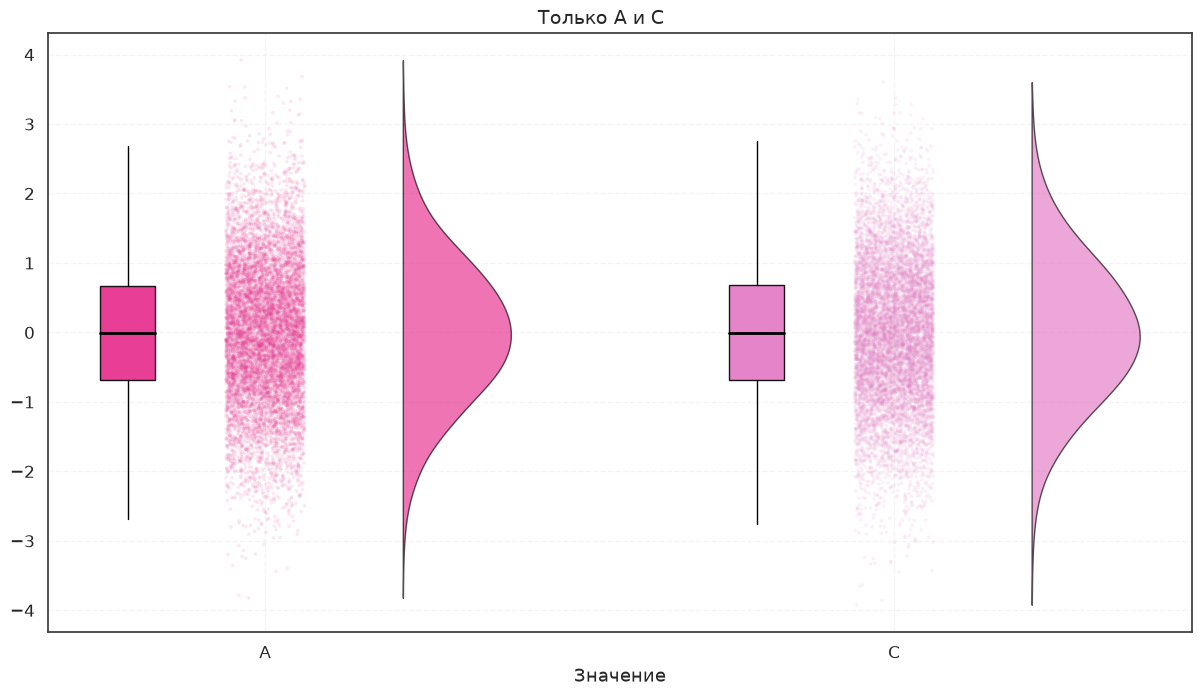

(<Figure size 1200x700 with 1 Axes>, [<Axes: xlabel='Значение'>])

In [31]:
# Всё на одном графике
raincloud_auto(
    df,
    features=['A', 'C'],
    combine=True,
    fig_title='Только A и C',
)

/tmp/ipykernel_22867/550273108.py:290: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=tight_pad)


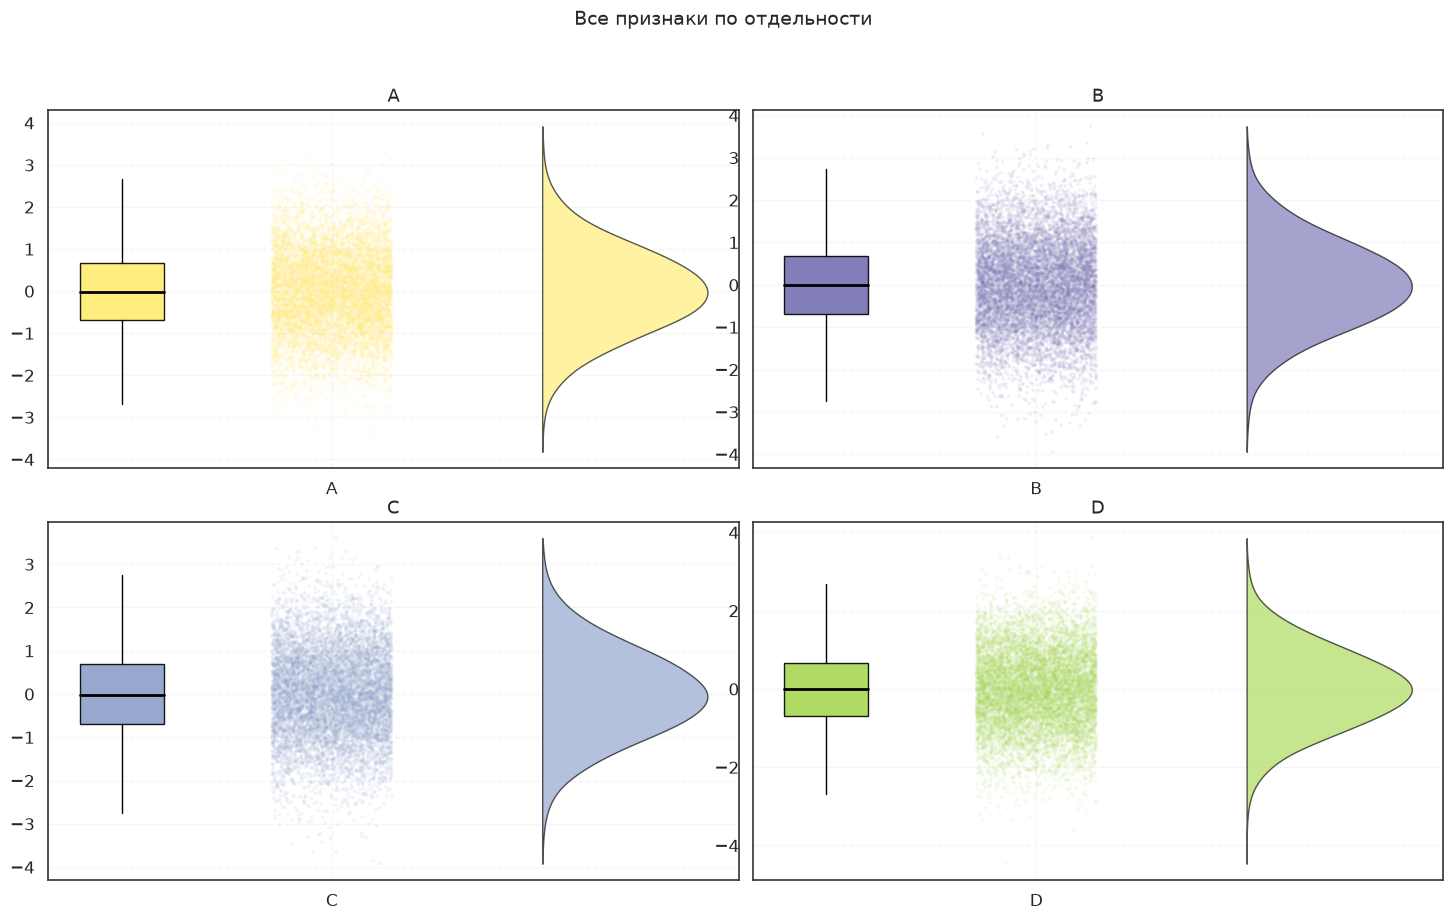

(<Figure size 1800x1000 with 4 Axes>,
 [<Axes: title={'center': 'A'}>,
  <Axes: title={'center': 'B'}>,
  <Axes: title={'center': 'C'}>,
  <Axes: title={'center': 'D'}>])

In [32]:
# Возьмёт все колонки, кроме target (если указан)
raincloud_auto(
    df,
    features=None,
    target='class',      # эту колонку пропустить
    combine=False,
    ncols=2,
    fig_title='Все признаки по отдельности',
)

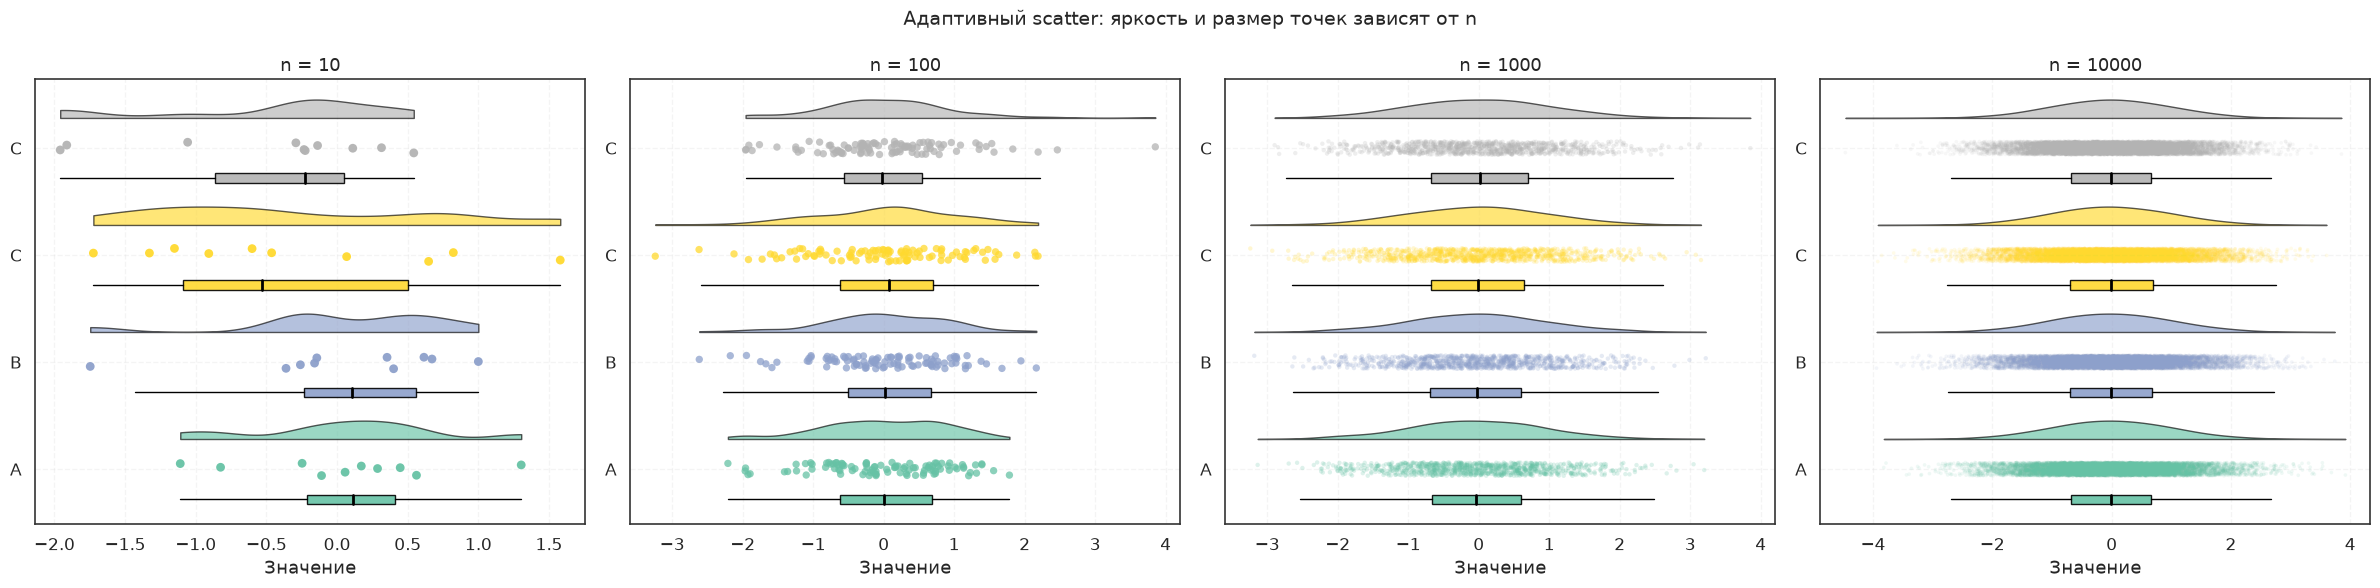

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Генерация датасетов разных размеров
# ============================================================
np.random.seed(42)
mean = [0, 0, 0, 0]
cov = [[1.0, 0.9, 0.0, 0.0],
       [0.9, 1.0, 0.0, 0.0],
       [0.0, 0.0, 1.0, 0.0],
       [0.0, 0.0, 0.0, 1.0]]

sizes = [10, 100, 1000, 10000]
datasets_by_size = {}
for n in sizes:
    np.random.seed(42)
    d = np.random.multivariate_normal(mean, cov, size=n)
    datasets_by_size[n] = pd.DataFrame(d, columns=['A', 'B', 'C', 'D'])

# ============================================================
# Четыре подграфика: 1 строка × 4 колонки
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=False)

for ax, n in zip(axes, sizes):
    df_n = datasets_by_size[n]
    raincloud(
        [df_n['A'].values, df_n['B'].values, df_n['C'].values, df_n['D'].values],
        ax=ax,                              # ← ВАЖНО: передаём существующий ax
        labels=['A', 'B', 'C', 'C'],
        values_on_y=False,
        violin_offset=0.45,
        scatter_offset=0.0,
        box_offset=0.45,
        violin_side='upper',
        title=f'n = {n}',
        xlabel='Значение',
    )

plt.suptitle('Адаптивный scatter: яркость и размер точек зависят от n', fontsize=14)
plt.tight_layout()
plt.show()